In [194]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [195]:
from urllib.request import urlretrieve

In [196]:
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x22b6b45e140>)

In [197]:
import pandas as pd

In [198]:
medical_df = pd.read_csv('medical.csv')

In [199]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [200]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [201]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [202]:
%pip install matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [203]:
import plotly.express as px 
import matplotlib.pyplot as plt 
import seaborn as sns



In [204]:
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['figure.facecolor'] = '#00000000'



In [205]:
fig = px.histogram(medical_df, x = 'age', marginal = 'box',color_discrete_sequence=['red'], nbins = 47, title = 'Distribution of Age')  
fig.update_layout(bargap = 0.1) # add the gap between bars
fig.show()

In [206]:
fig = px.histogram(medical_df,
                   x = 'age', 
                   marginal= 'box', 
                   color= 'sex', 
                   color_discrete_sequence = ["orange", 'green'], 
                   title = 'Annual Medical Charges')
fig.update_layout(bargap= 0.1)
fig.show()

In [207]:
px.histogram(medical_df, x = 'sex', color = 'smoker', title = 'Sex')


In [208]:
fig = px.scatter(medical_df, 
                 x='age', 
                 y='charges', 
                 color='smoker', 
                 opacity=0.8, 
                 hover_data=['sex'], 
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [209]:
fig = px.scatter(medical_df, 
                 x = 'bmi',
                 y='charges',
                 color = 'smoker',
                 opacity = 0.8, 
                 hover_data = ['sex'],
                 title = 'BMI vs. Charges')
fig.update_traces(marker_size = 5)
fig.show()

In [210]:
# correlation (A positive sign means the values grow together; a negative sign means one decreases as the other increases.) and 0 means no correlation. The closer the value is to 1 or -1, the stronger the correlation.

In [211]:
medical_df.charges.corr(medical_df.age) 

np.float64(0.2990081933306478)

In [212]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362887)

In [213]:
smoker_charges = {'yes' :1, 'no' : 0}
smoker_numberic = medical_df.smoker.map(smoker_charges)
medical_df.charges.corr(smoker_numberic) # output is 0.78 which close to 1 means that smoker_numberic and charges are positively correlated. This means that as the smoker_numberic increases, the charges also increase. In other words, smokers tend to have higher medical charges than non-smokers.

np.float64(0.7872514304984778)

In [214]:
medical_df['sex_code'] = medical_df.sex.map({'female':0, 'male':1})
medical_df['region_code'] = medical_df.region.map({'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3})
medical_df['smoker_code'] = medical_df.smoker.map({'no':0, 'yes':1})
medical_df.corr(numeric_only = True)

,age,bmi,children,charges,sex_code,region_code,smoker_code
age,1.000000,0.109272,0.042469,0.299008,-0.020856,-0.002127,-0.025019
bmi,0.109272,1.000000,0.012759,0.198341,0.046371,-0.157566,0.003750
children,0.042469,0.012759,1.000000,0.067998,0.017163,-0.016569,0.007673
charges,0.299008,0.198341,0.067998,1.000000,0.057292,0.006208,0.787251
sex_code,-0.020856,0.046371,0.017163,0.057292,1.000000,-0.004588,0.076185
region_code,-0.002127,-0.157566,-0.016569,0.006208,-0.004588,1.000000,0.002181
smoker_code,-0.025019,0.003750,0.007673,0.787251,0.076185,0.002181,1.000000


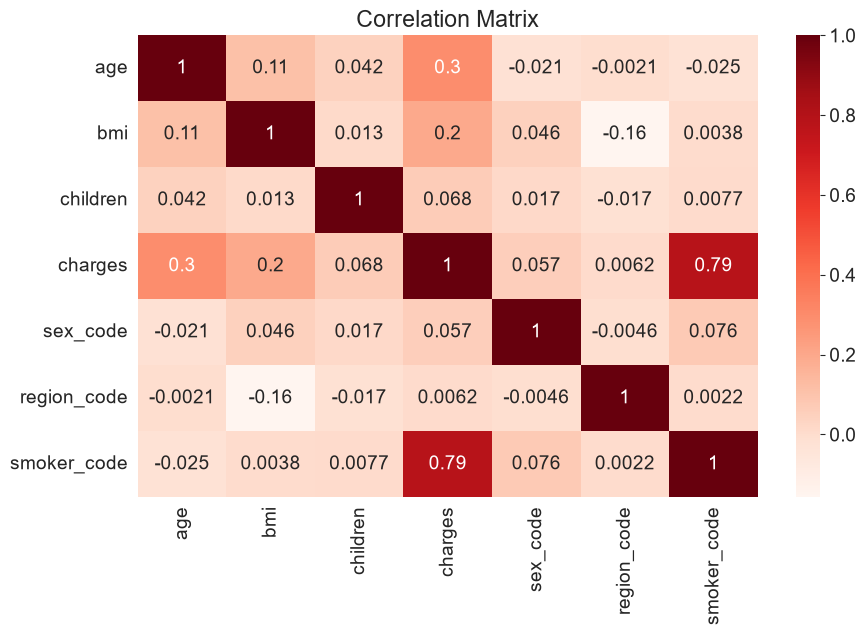

In [215]:
sns.heatmap(medical_df.corr(numeric_only = True), annot = True, cmap = 'Reds')
plt.title('Correlation Matrix');

<Axes: title={'center': 'Age Vs Charges'}, xlabel='age', ylabel='charges'>

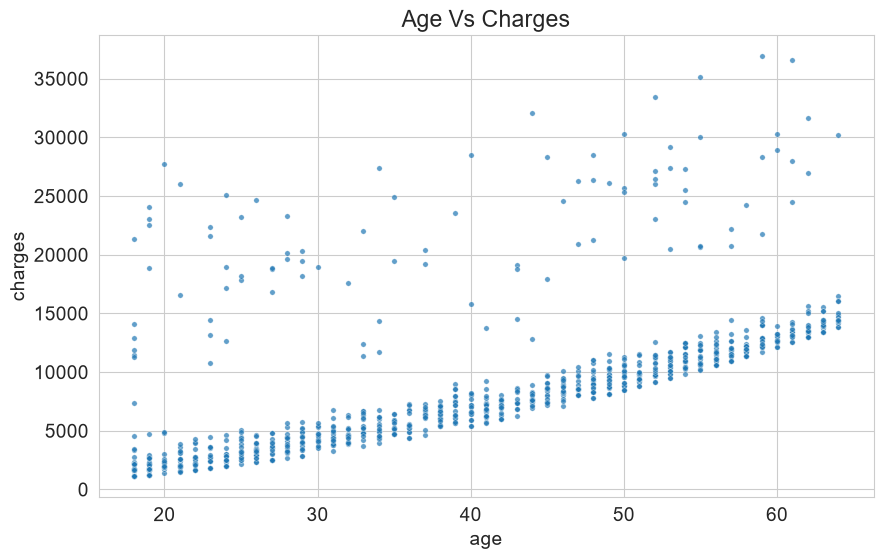

In [216]:
non_smoker_df = medical_df[medical_df.smoker =='no']
plt.title ('Age Vs Charges')
sns.scatterplot(data=non_smoker_df, x = 'age', y= 'charges', alpha = 0.7, s = 15)

In [217]:
#charges = w*age + b , To get linear regression , (y = wx+b)
def estimated_charge(age, w, b):
  return w*age + b

In [218]:
w =50
b = 100 # just assume to get linear regression
ages = non_smoker_df.age
estimated_charges = estimated_charge(ages, w ,b)

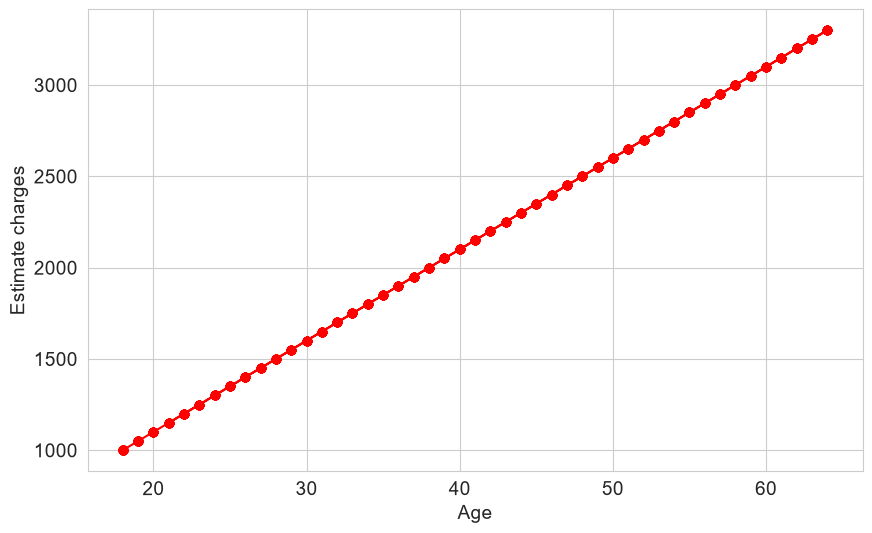

In [219]:
plt.plot(ages, estimated_charges, 'r-o');
plt.xlabel('Age');
plt.ylabel('Estimate charges');

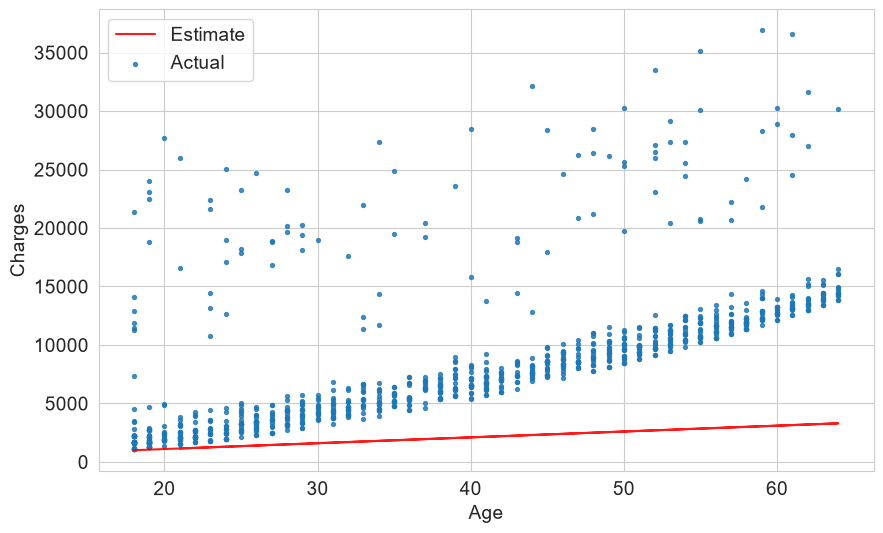

In [220]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha = 0.9 );
plt.scatter(ages, target, s=8, alpha=0.8);
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate','Actual']);

In [221]:
# loss/cost function
import numpy as np
def rmse(targets, predictions):
  return np.sqrt(np.mean((targets - predictions)**2))  

In [222]:
#guess again seem like the graph above doesn't fit the data
def try_paramaters(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges 
  
  prediction = estimated_charge(ages, w, b)
    
  plt.plot(ages, prediction, 'r', alpha=0.9); # x = ages, y = estimated_charges /predition
  plt.scatter(ages, target, s=8, alpha = 0.8); # x = ages, y = target(actual charges) , compare each other
  plt.xlabel('Ages')
  plt.ylabel('Charges')
  plt.legend(['Predicted', 'Actual'])
  loss = rmse(target, prediction)
  print(f'RMSE: {loss:.2f}')

RMSE: 8044.91


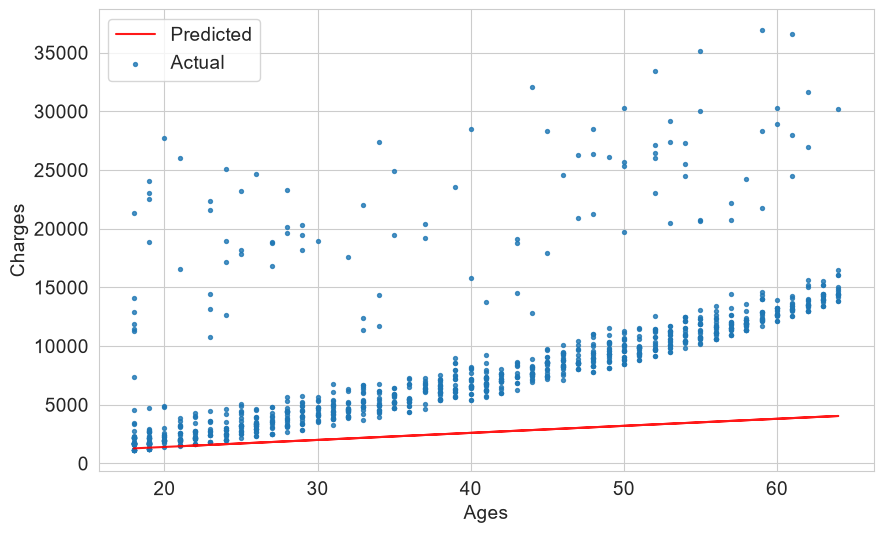

In [223]:
try_paramaters(60,200) #still doesn't look fit for the data 

RMSE: 4662.51


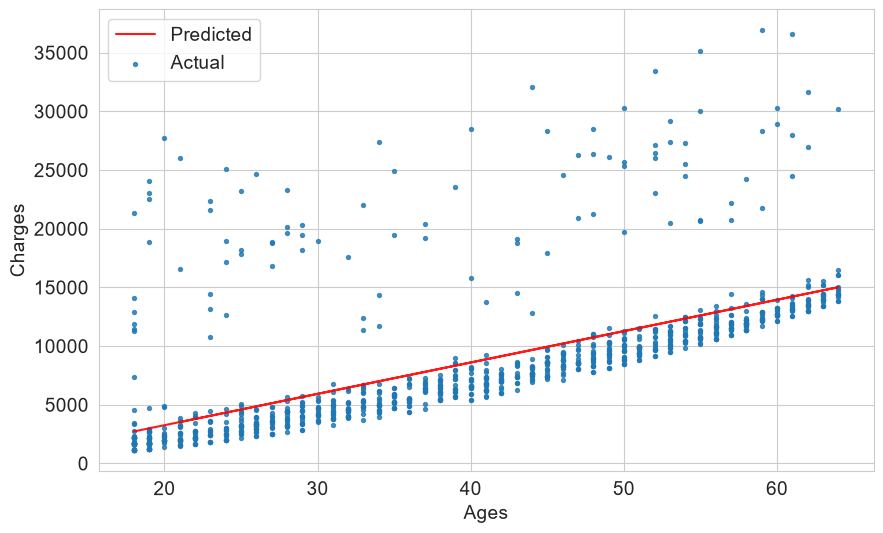

In [224]:
try_paramaters(267.25,-2091.42) # if we do it with scikit.learn linear regression, we will get the weight and bias as 267.25 and -2091.42 respectively. This is a better fit for the data.

In [225]:
import numpy as np
def rmse(targets, predictions):
  return np.sqrt(np.mean((targets - predictions)**2))

In [226]:
targets= non_smoker_df['charges']
predicted = estimated_charge(ages, w, b)
#w=50, b=100

In [227]:
rmse(targets, predicted)

np.float64(8461.949562575493)